In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# sigmoid 함수 정의
def sigmoid(x):
    return 1.0/(1.0 + np.exp(-x))

# parameter 초기값 지정
def init_network(input_dim, hidden_dim, output_dim):
    W1 = np.random.randn(input_dim, hidden_dim) # (2, 2)
    b1 = np.random.randn(hidden_dim) # bias 2개 (2,)
    W2 = np.random.randn(hidden_dim, output_dim ) # (2, 1)
    b2 = np.random.randn(output_dim) # bias 1개 (1,)
    return W1, b1, W2, b2

# 순전파
def forward(x, W1, b1, W2, b2):
    z = sigmoid(np.matmul(x, W1) - b1) # hidden activity (4, 2)
    y = sigmoid(np.matmul(z, W2) - b2) # 출력값 y를 predict (4, 1)
    return z, y

# 역전파
def backward(x, true_y, W1, b1, W2, b2, lr=0.01): # lr는 learning rate
    z, y = forward(x, W1, b1, W2, b2) # prediction구하기 (이걸 구해야 에러를 구할 수 있음)
    """
    dLdw2 = dLdy * dyds2 * ds2dw2 =  -(y_true-y) *  y(1-y) * z = error_y * z 
    dLdb2 = dLdy * dyds2 * ds2db2 =  -(y_true-y) *  y(1-y) * (-1) = error_y * (-1)
    dLdw1 = dLdy * dyds2 * ds2dz * dzds1 * ds1dw1 = -(y_true-y) *  y(1-y) * w2 * z(1-z) * x = error_z * x
    dLdb1 = dLdy * dyds2 * ds2dz * dzds1 * ds1db1 = -(y_true-y) *  y(1-y) * w2 * z(1-z) * (-1) = error_z * (-1)
    error_y = -(y_true-y) *  y(1-y)
    error_z = error_y * w2 * z(1-z) 
    """
    error_y = (true_y - y)*y*(1-y) # (4, 1) * (4, 1) * (4, 1) = (4, 1)
    error_z = error_y.dot(W2.T)*z*(1-z) # ((4, 1) * (1, 2)) * (4, 2) * (4, 2) = (4, 2)
    
    dLdW2 = np.matmul(z.T, error_y) # (2, 4) * (4, 1) = (2, 1)
    dLdW1 = np.matmul(x.T, error_z) # (2, 4) * (4, 2) = (2, 2)
    dLdb2 = np.sum(error_y,axis=0)*(-1.) # (4, 1)을 열 방향으로 합치면 (1,)
    dLdb1 = np.sum(error_z,axis=0)*(-1.) # (4, 2)을 열 방향으로 합치면 (2,)
    
    W2 = W2 + lr * dLdW2
    W1 = W1 + lr * dLdW1
    b2 = b2 + lr * dLdb2
    b1 = b1 + lr * dLdb1
    
    return W1, b1, W2, b2

In [4]:
# XOR 문제 정의
x = np.array([[0,0], [0,1],[1,0],[1,1]]) # (4, 2)
true_y = np.array([[0.], [1.], [1.], [0.]]) # (4, 1)
epoch_num = 10000 # 업데이트 횟수

In [5]:
# 초기값
W1, b1, W2, b2 = init_network(input_dim=2, hidden_dim=2, output_dim=1) 
print(W1, W1.shape)
print(b1, b1.shape)
print(W2, W2.shape)
print(b2, b2.shape)

[[ 1.53085717 -0.25015376]
 [ 0.0619951   0.26271754]] (2, 2)
[0.09379256 0.42398379] (2,)
[[-0.12580611]
 [-0.73801011]] (2, 1)
[0.76396156] (1,)


epoch: 0/10000, error: 1.254
epoch: 1000/10000, error: 0.992
epoch: 2000/10000, error: 0.909
epoch: 3000/10000, error: 0.659
epoch: 4000/10000, error: 0.211
epoch: 5000/10000, error: 0.068
epoch: 6000/10000, error: 0.036
epoch: 7000/10000, error: 0.024
epoch: 8000/10000, error: 0.017
epoch: 9000/10000, error: 0.014


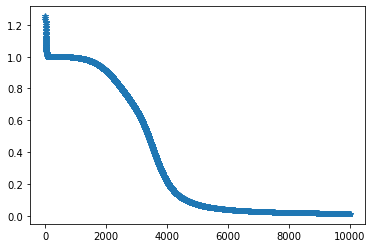

In [6]:
# train
epoch_dat = []
error_dat = [] # 각 epoch에 해당하는 에러
for epoch in range(epoch_num):
    W1, b1, W2, b2 = backward(x, true_y, W1, b1, W2, b2, lr=0.1) # 업데이트
    z, y = forward(x, W1, b1, W2, b2) # y값 대시 예측
    error = true_y - y # 에러 구하기
    train_error = np.sum(error*error) # 모든 샘플에 대한 에러 더하기
    epoch_dat.append(epoch)
    error_dat.append(train_error)        
    
    if epoch % 1000 == 0: # 천 번에 한 번은 결과를 보여줘라
        print( 'epoch: %d/%d, error: %.3f'%(epoch, epoch_num, train_error))

plt.plot(epoch_dat, error_dat, '-*')
plt.show()

In [8]:
print(W1, b1, W2, b2)

[[5.76625335 3.81069242]
 [5.76156058 3.80965123]] [2.42556576 5.84225589] [[ 7.57431857]
 [-8.19476868]] [3.42843091]


In [9]:
print(y)

[[0.05536877]
 [0.94962272]
 [0.9496372 ]
 [0.05389796]]
